## Visualizing background error covariance

### Environment Setup

In [2]:
# Import package
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt
    
# Path setup
root_path: Path = Path("/Users/joseph/Desktop/NTU Course/114-2/Data Assimilation/Project")
file_path: Path = root_path / "Files"
fig_path : Path = root_path / "Figure"


### Load data

In [3]:
# Load climatology BEC
clim_BEC: np.ndarray = np.load(file_path / "climatology_BEC.npz")["all"]*1e-3

# Load NMC BEC
nmc_BEC: np.ndarray = np.load(file_path / "NMC_BEC.npz")["all"]*1e-1



### Visualization

#### Global setting

In [4]:
plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "figure.dpi": 300,
        "axes.grid": False,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.constrained_layout.use": True
    })

#### Visualize

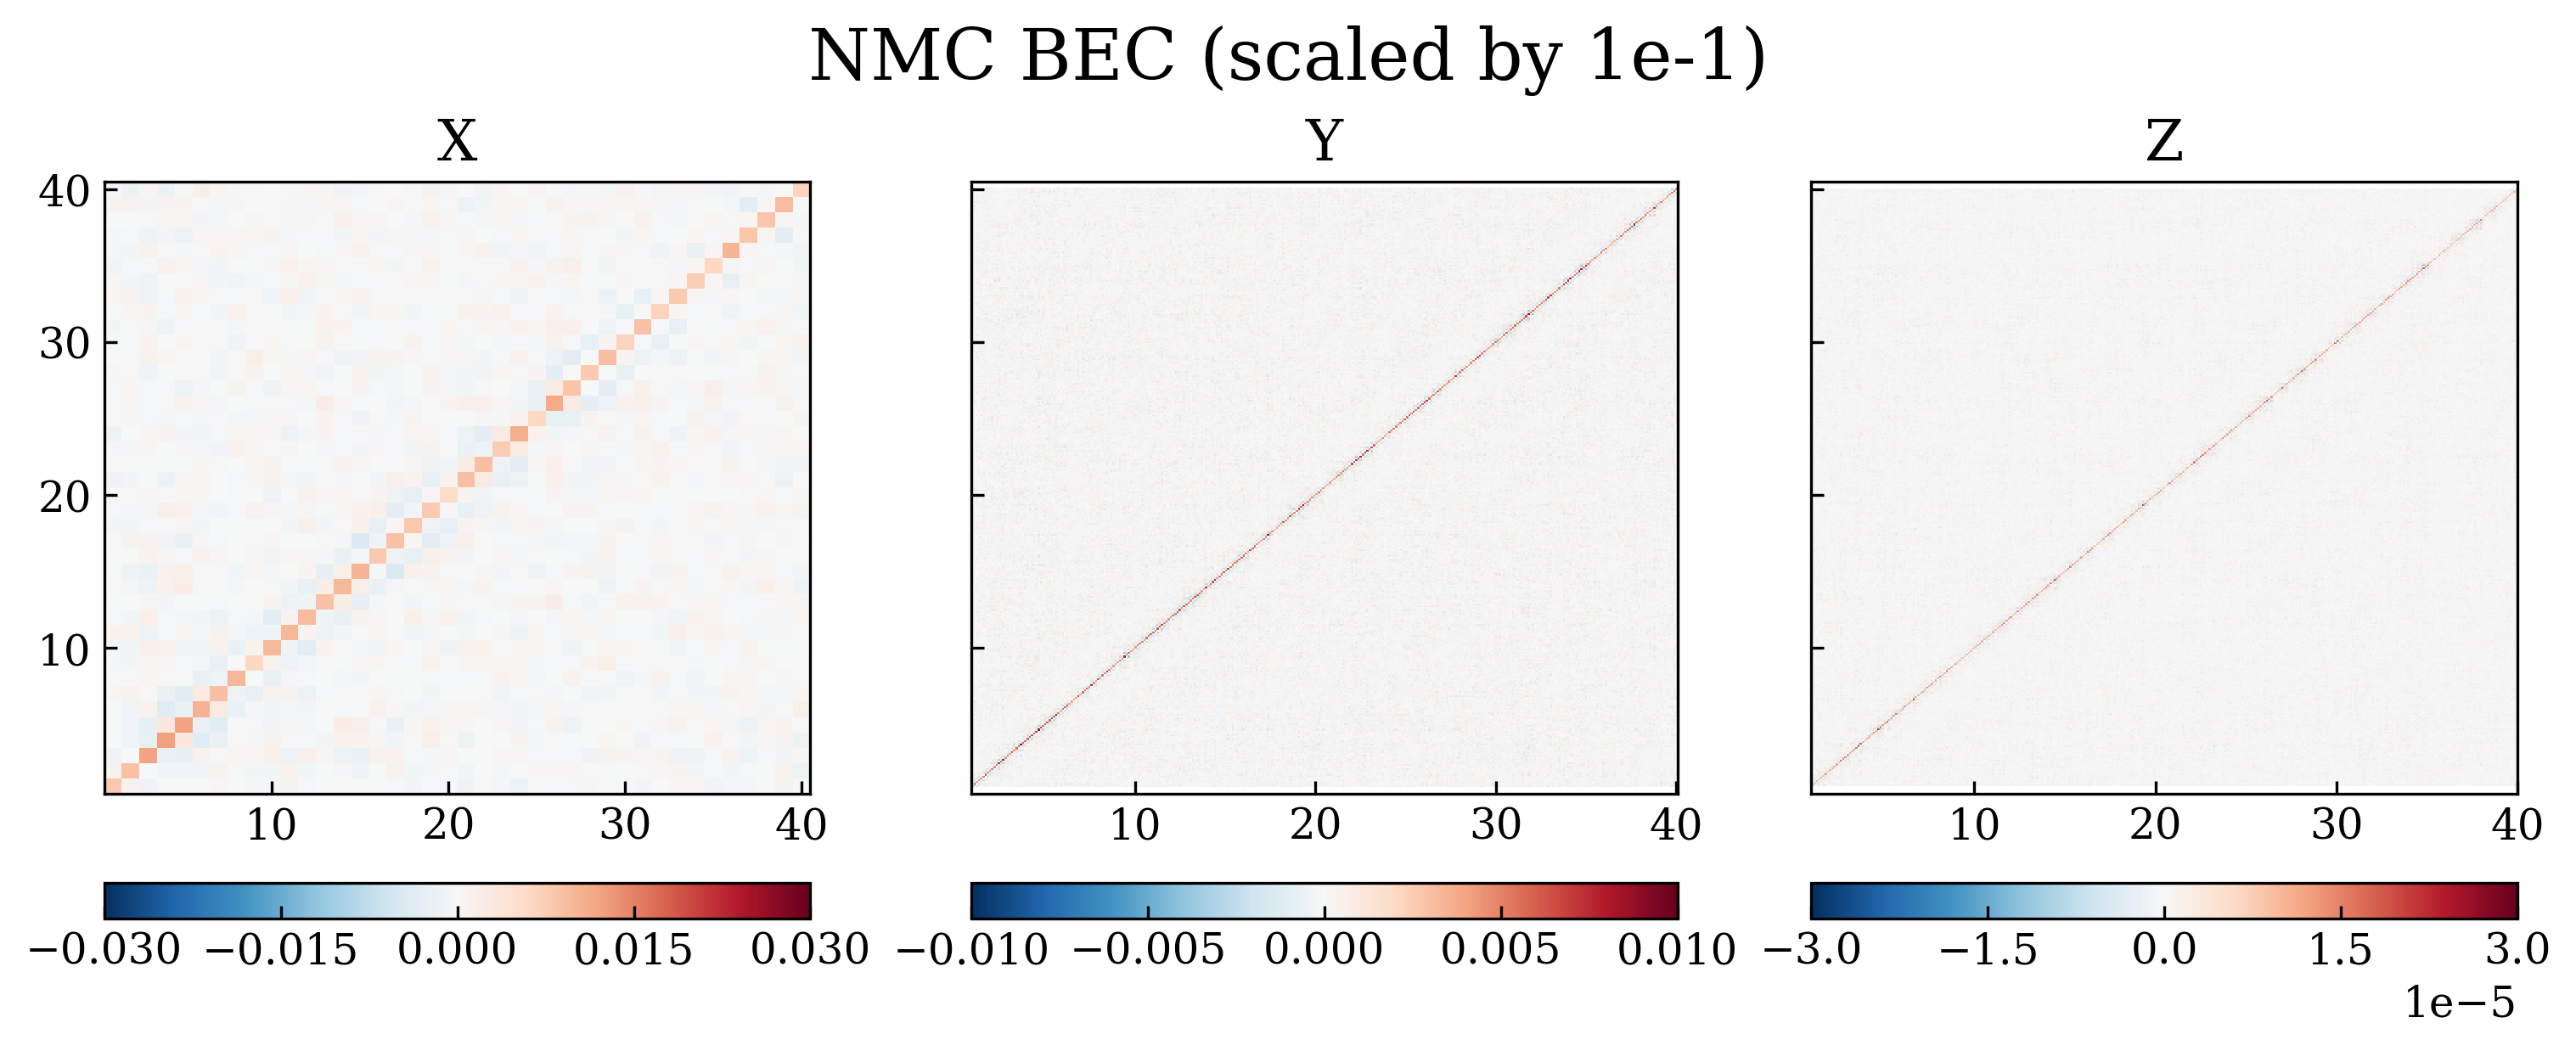

In [8]:
fig, axes = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(10, 4))

x_pcm = axes[0].pcolormesh(
    np.linspace(1, 40, 40), 
    np.linspace(1, 40, 40),
    nmc_BEC[:40, :40], cmap="RdBu_r",
    vmin=-0.03, vmax=0.03
    )

axes[0].set_title("X")
cbarx = fig.colorbar(x_pcm, ax=axes[0], orientation="horizontal")
cbarx.set_ticks([-0.03, -0.015, 0, 0.015, 0.03])

nmc_y = axes[1].pcolormesh(
    np.linspace(1, 40, 320),
    np.linspace(1, 40, 320),
    nmc_BEC[40:360, 40:360], cmap="RdBu_r",
    vmin=-0.01, vmax=0.01
    )
cbary = fig.colorbar(nmc_y, ax=axes[1], orientation="horizontal")
cbary.set_ticks([-0.01, -0.005, 0, 0.005, 0.01])

axes[1].set_title("Y")

nmc_z = axes[2].pcolormesh(
    np.linspace(1, 40, 2560),
    np.linspace(1, 40, 2560),
    nmc_BEC[360:, 360:], cmap="RdBu_r",
    vmin=-3e-5, vmax=3e-5
    )

cbarz = fig.colorbar(nmc_z, ax=axes[2], orientation="horizontal")
cbarz.set_ticks([-3e-5, -1.5e-5, 0, 1.5e-5, 3e-5])

axes[2].set_title("Z")
plt.suptitle("NMC BEC (scaled by 1e-1)", fontsize=20)
plt.savefig(fig_path / "BEC_contrast.png", dpi=300, bbox_inches="tight")

